In [ ]:
#Import Libraries and Setup
!pip uninstall -y numpy
!pip install medmnist==3.0.2 monai captum -q

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

from monai.transforms import (
    Compose, EnsureChannelFirst, Resize,
    RandFlip, RandRotate90, RandZoom
)

from captum.attr import Saliency, IntegratedGradients, LayerGradCam, LayerAttribution

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
def EDA_3D(dataset, title=""):
    print(f"Dataset: {title}, len={len(dataset)}")
    x, y = dataset[0]
    print("Sample shape:", x.shape, "Label:", y)

    # mid‑slice visualization for a few samples
    fig, axs = plt.subplots(2, 4, figsize=(12,6))
    for ax in axs.flatten():
        idx = np.random.randint(0, len(dataset))
        vol, label = dataset[idx]
        vol = vol[0].numpy()  # (D,H,W)
        d = vol.shape[0] // 2
        ax.imshow(vol[d], cmap="gray")
        ax.set_title(f"y={label}")
        ax.axis("off")
    plt.suptitle(f"{title} mid‑slices")
    plt.show()


In [ ]:
class MedMNIST3D:
    def __call__(self, img):
        # MedMNIST 3D can be (D,H,W,1); squeeze to (D,H,W)
        return np.squeeze(img)

def load_medmnist_3d(flag="organmnist3d", batch_size=4, spatial_size=(64,64,64)):
    info = INFO[flag]
    DataClass = getattr(medmnist, info["python_class"])

    train_tf = Compose([
        MedMNIST3D(),
        EnsureChannelFirst(channel_dim="no_channel"),
        Resize(spatial_size),
        RandFlip(spatial_axis=[0,1,2], prob=0.5),
        RandRotate90(prob=0.5, max_k=3, spatial_axes=(0,1)),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ])

    eval_tf = Compose([
        MedMNIST3D(),
        EnsureChannelFirst(channel_dim="no_channel"),
        Resize(spatial_size),
    ])

    train_ds = DataClass(split="train", transform=train_tf, download=True)
    val_ds   = DataClass(split="val",   transform=eval_tf, download=True)
    test_ds  = DataClass(split="test",  transform=eval_tf, download=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, info


In [ ]:
load_medmnist_3d(flag="organmnist3d", batch_size=4, spatial_size=(64,64,64))

100%|██████████| 32.7M/32.7M [00:02<00:00, 11.8MB/s]


(Dataset OrganMNIST3D of size 28 (organmnist3d)
     Number of datapoints: 971
     Root location: /root/.medmnist
     Split: train
     Task: multi-class
     Number of channels: 1
     Meaning of labels: {'0': 'liver', '1': 'kidney-right', '2': 'kidney-left', '3': 'femur-right', '4': 'femur-left', '5': 'bladder', '6': 'heart', '7': 'lung-right', '8': 'lung-left', '9': 'spleen', '10': 'pancreas'}
     Number of samples: {'train': 971, 'val': 161, 'test': 610}
     Description: The source of the OrganMNIST3D is the same as that of the Organ{A,C,S}MNIST. Instead of 2D images, we directly use the 3D bounding boxes and process the images into 28×28×28 to perform multi-class classification of 11 body organs. The same 115 and 16 CT scans as the Organ{A,C,S}MNIST from the source training set are used as training and validation set, respectively, and the same 70 CT scans as the Organ{A,C,S}MNIST from the source test set are treated as the test set.
     License: CC BY 4.0,
 Dataset OrganMNIS

Dataset: organmnist3d, len=971
Sample shape: torch.Size([1, 64, 64, 64]) Label: [3]


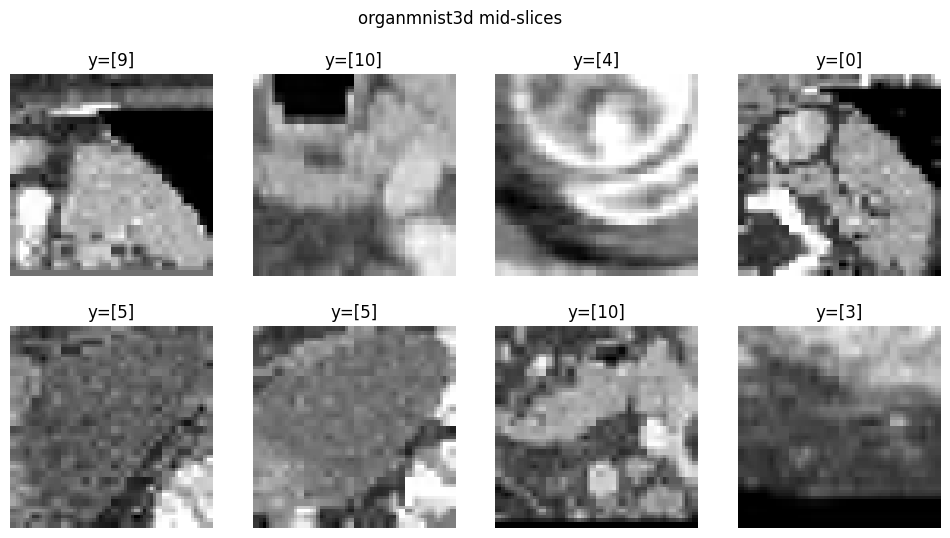

In [ ]:
flag = "organmnist3d"
info = INFO[flag]
DataClass = getattr(medmnist, info["python_class"])

# MONAI-compatible transform
tf = Compose([
    MedMNIST3D(),                                # remove trailing channel
    EnsureChannelFirst(channel_dim="no_channel"),   # convert to (1, D, H, W)
    Resize((64,64,64)),                             # resize volume
])

# Load dataset
ds = DataClass(split="train", transform=tf, download=True)

# EDA function
EDA_3D(ds, title=flag)


Dataset: organmnist3d, len=971
Sample shape: torch.Size([1, 64, 64, 64]) Label: [3]


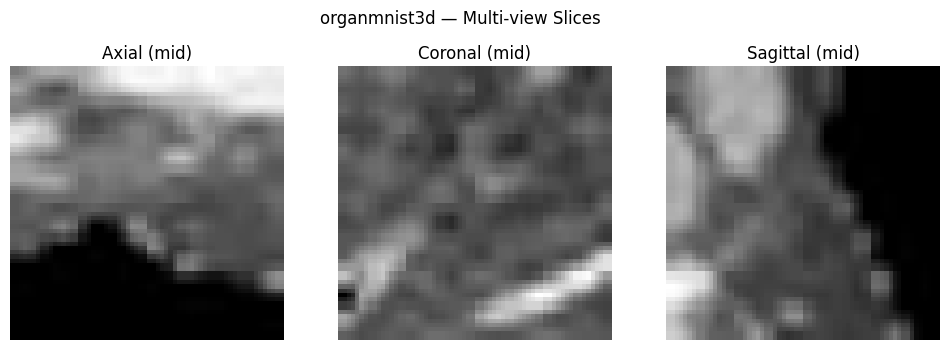

In [ ]:
def EDA_3D_multiview(dataset, title=""):
    print(f"Dataset: {title}, len={len(dataset)}")
    x, y = dataset[0]
    print("Sample shape:", x.shape, "Label:", y)

    vol = x[0].numpy()  # (D,H,W)
    D, H, W = vol.shape

    mid_d = D // 2
    mid_h = H // 2
    mid_w = W // 2

    axial    = vol[mid_d]
    coronal  = vol[:, mid_h, :]
    sagittal = vol[:, :, mid_w]

    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    axs[0].imshow(axial, cmap="gray");    axs[0].set_title("Axial (mid)");    axs[0].axis("off")
    axs[1].imshow(coronal, cmap="gray");  axs[1].set_title("Coronal (mid)");  axs[1].axis("off")
    axs[2].imshow(sagittal, cmap="gray"); axs[2].set_title("Sagittal (mid)"); axs[2].axis("off")

    plt.suptitle(f"{title} — Multi‑view Slices")

    plt.show()
EDA_3D_multiview(ds, title=flag)

In [ ]:
from matplotlib import animation
from IPython.display import HTML

def animate_3d_volume(vol, title="3D Scroll Animation"):
    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()

    def update(i):
        ax.clear()
        ax.imshow(vol[i], cmap="gray")
        ax.set_title(f"{title} — Slice {i}")
        ax.axis("off")

    anim = animation.FuncAnimation(fig, update, frames=vol.shape[0], interval=80)
    plt.close(fig)
    return anim

vol = ds[1][0][0].numpy()
anim = animate_3d_volume(vol, title="OrganMNIST3D")
HTML(anim.to_html5_video())


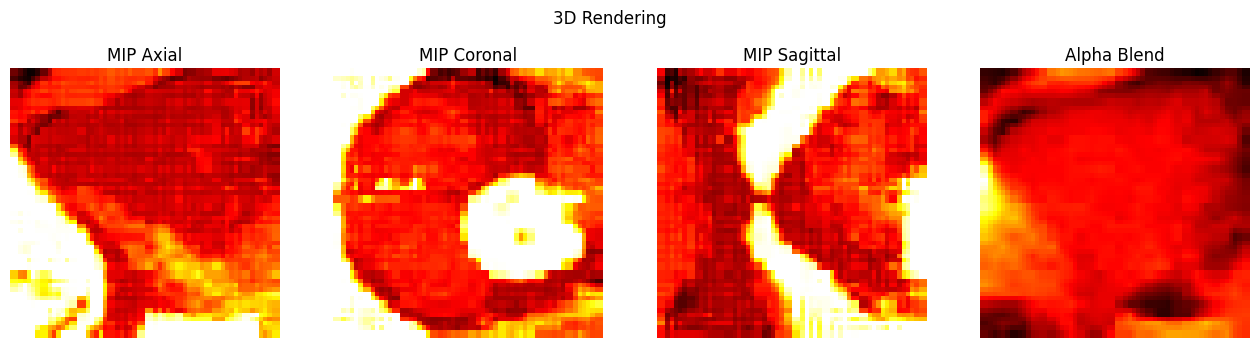

In [ ]:
def render_3D_volume(vol, title="3D Rendering"):
    vol = vol.astype(float)

    mip_axial    = vol.max(axis=0)
    mip_coronal  = vol.max(axis=1)
    mip_sagittal = vol.max(axis=2)

    alpha = vol.mean(axis=0)  # simple alpha blend

    fig, axs = plt.subplots(1, 4, figsize=(16,4))
    axs[0].imshow(mip_axial, cmap="hot");    axs[0].set_title("MIP Axial");    axs[0].axis("off")
    axs[1].imshow(mip_coronal, cmap="hot");  axs[1].set_title("MIP Coronal");  axs[1].axis("off")
    axs[2].imshow(mip_sagittal, cmap="hot"); axs[2].set_title("MIP Sagittal"); axs[2].axis("off")
    axs[3].imshow(alpha, cmap="hot");        axs[3].set_title("Alpha Blend");  axs[3].axis("off")

    plt.suptitle(title)
    plt.show()

vol = ds[1][0][0].numpy()
render_3D_volume(vol, title="3D Rendering")


In [ ]:
def Full_EDA_3D(dataset, title=""):
    print(f"Dataset: {title}, len={len(dataset)}")
    x, y = dataset[0]
    print("Sample shape:", x.shape, "Label:", y)

    vol = x[0].numpy()  # (D,H,W)

    D, H, W = vol.shape
    mid_d = D // 2
    mid_h = H // 2
    mid_w = W // 2

    # Prepare slices
    axial      = vol[mid_d]          # (H,W)
    coronal    = vol[:, mid_h, :]    # (D,W)
    sagittal   = vol[:, :, mid_w]    # (D,H)

    # Random slices
    rand_d = np.random.randint(0, D)
    rand_h = np.random.randint(0, H)
    rand_w = np.random.randint(0, W)

    rand_axial    = vol[rand_d]
    rand_coronal  = vol[:, rand_h, :]
    rand_sagittal = vol[:, :, rand_w]

    # Plot
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))

    axs[0,0].imshow(axial, cmap="gray")
    axs[0,0].set_title("Axial (mid)")
    axs[0,0].axis("off")

    axs[0,1].imshow(coronal, cmap="gray")
    axs[0,1].set_title("Coronal (mid)")
    axs[0,1].axis("off")

    axs[0,2].imshow(sagittal, cmap="gray")
    axs[0,2].set_title("Sagittal (mid)")
    axs[0,2].axis("off")

    axs[1,0].imshow(rand_axial, cmap="gray")
    axs[1,0].set_title(f"Axial (rand={rand_d})")
    axs[1,0].axis("off")

    axs[1,1].imshow(rand_coronal, cmap="gray")
    axs[1,1].set_title(f"Coronal (rand={rand_h})")
    axs[1,1].axis("off")

    axs[1,2].imshow(rand_sagittal, cmap="gray")
    axs[1,2].set_title(f"Sagittal (rand={rand_w})")
    axs[1,2].axis("off")

    plt.suptitle(f"{title} — 3D Visualization")
    plt.show()



Running EDA for: organmnist3d
Dataset: organmnist3d, len=971
Sample shape: torch.Size([1, 64, 64, 64]) Label: [3]


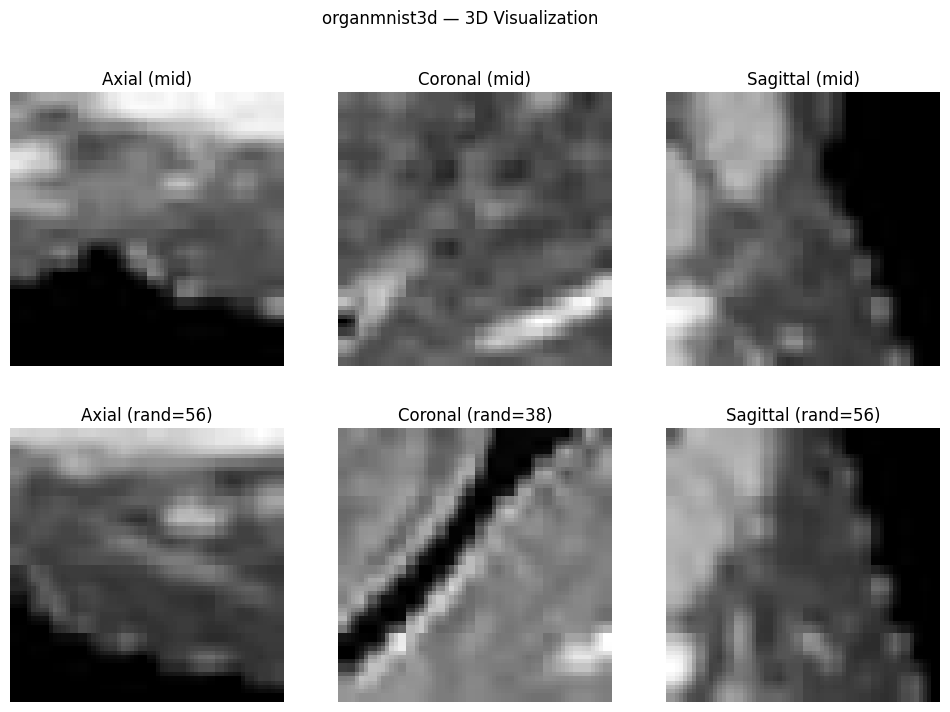


Running EDA for: nodulemnist3d


100%|██████████| 29.3M/29.3M [00:02<00:00, 11.3MB/s]


Dataset: nodulemnist3d, len=1158
Sample shape: torch.Size([1, 64, 64, 64]) Label: [0]


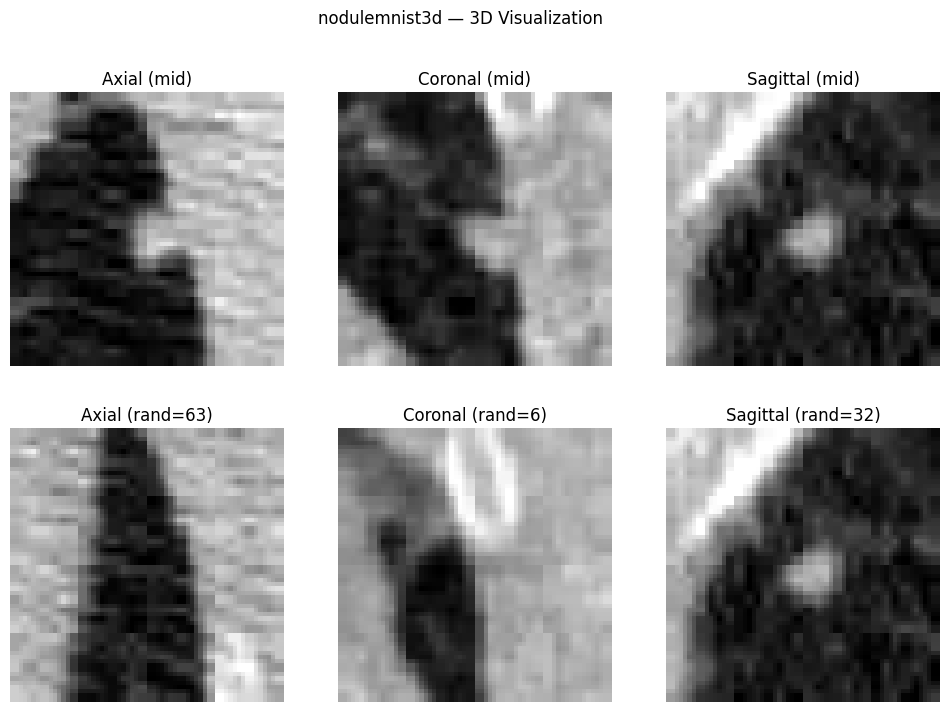


Running EDA for: adrenalmnist3d


100%|██████████| 277k/277k [00:00<00:00, 434kB/s]


Dataset: adrenalmnist3d, len=1188
Sample shape: torch.Size([1, 64, 64, 64]) Label: [0]


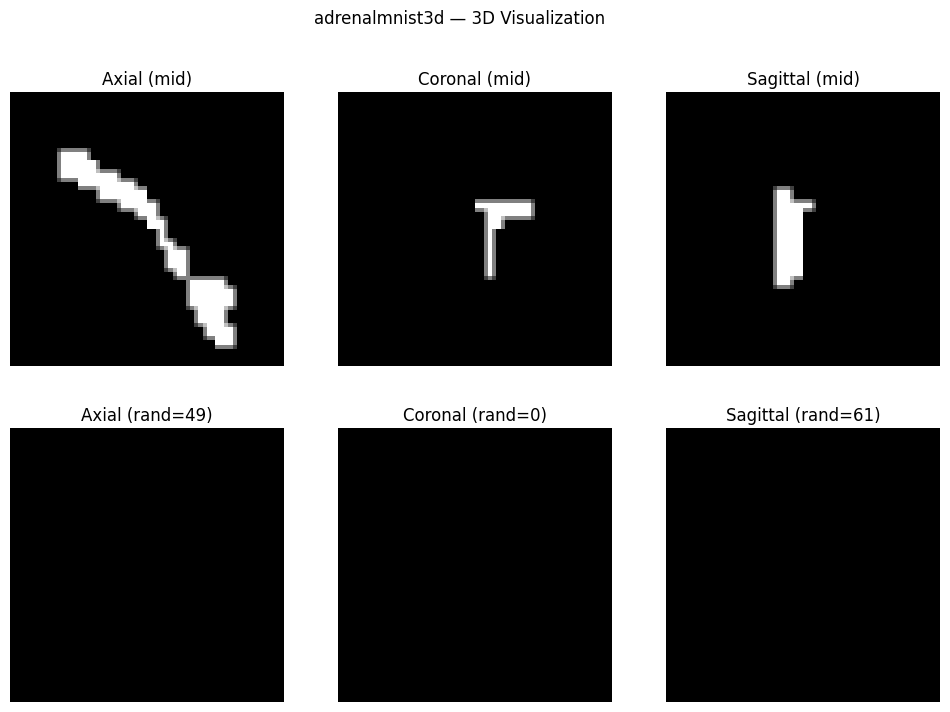

In [ ]:
datasets = [
    "organmnist3d",
    "nodulemnist3d",
    "adrenalmnist3d"
]

for flag in datasets:
    print("\n==============================")
    print(f"Running EDA for: {flag}")
    print("==============================")

    info = INFO[flag]
    DataClass = getattr(medmnist, info["python_class"])

    tf = Compose([
        MedMNIST3D(),
        EnsureChannelFirst(channel_dim="no_channel"),
        Resize((64,64,64)),
    ])

    ds = DataClass(split="train", transform=tf, download=True)

    Full_EDA_3D(ds, title=flag)


In [ ]:
#Model Architecture

class CNN3D(nn.Module):
    def __init__(self, num_classes, input_shape=(64,64,64)):
        super().__init__()
        self.conv1 = nn.Conv3d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv3d(16, 32, 3, padding=1)
        self.pool  = nn.MaxPool3d(2)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)
            x = self.pool(F.relu(self.conv1(dummy)))
            x = self.pool(F.relu(self.conv2(x)))
            self.flatten_dim = x.numel()

        self.fc1 = nn.Linear(self.flatten_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total, correct = 0, 0
    for x, y in loader:
        x = x.to(device)
        y = y.squeeze().long().to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()

        total += x.size(0)
    return correct / total

def evaluate(model, loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.squeeze().long().to(device)

            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()

            total += x.size(0)
    return correct / total


In [ ]:
#Captum attributes
def get_saliency_ig_gc(model, x, target_class):
    model.eval()
    x = x.to(device).requires_grad_(True)

    # Saliency
    sal = Saliency(model).attribute(
        x, target=target_class
    )[0,0].detach().cpu().numpy()

    # Integrated Gradients (Captum now uses baselines=)
    ig = IntegratedGradients(model).attribute(
        x,
        baselines=torch.zeros_like(x),   # <-- FIXED
        target=target_class,
        n_steps=40
    )[0,0].detach().cpu().numpy()

    # GradCAM
    gc = LayerGradCam(model, model.conv2).attribute(
        x, target=target_class
    )
    gc = LayerAttribution.interpolate(gc, x.shape[2:])[0,0].detach().cpu().numpy()

    return sal, ig, gc



In [ ]:
# Add GradCAM++
class GradCAMpp3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.layer = target_layer
        self.activations = None
        self.gradients = None

        def fwd_hook(module, inp, out):
            self.activations = out

        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.layer.register_forward_hook(fwd_hook)
        self.layer.register_backward_hook(bwd_hook)

    def __call__(self, x, target_class):
        self.model.zero_grad()
        out = self.model(x)
        score = out[:, target_class].sum()
        score.backward(retain_graph=True)

        A = self.activations          # (B,C,D,H,W)
        G = self.gradients            # (B,C,D,H,W)

        # GradCAM++ weights
        grad_2 = G ** 2
        grad_3 = G ** 3
        eps = 1e-8

        alpha_num = grad_2
        alpha_den = 2 * grad_2 + (A * grad_3).sum(dim=(2,3,4), keepdim=True) + eps
        alpha = alpha_num / alpha_den

        weights = (alpha * F.relu(G)).sum(dim=(2,3,4), keepdim=True)  # (B,C,1,1,1)

        cam = (weights * A).sum(dim=1, keepdim=True)                  # (B,1,D,H,W)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode="trilinear", align_corners=False)
        cam = cam[0,0].detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

In [ ]:
def visualize_3d_attributions(volume, sal, ig, gc, gcpp, title=""):
    d = volume.shape[0] // 2
    fig, axs = plt.subplots(1,5,figsize=(18,3))
    for ax, data, name in zip(
        axs,
        [volume[d], sal[d], ig[d], gc[d], gcpp[d]],
        ["Image","Saliency","IG","GradCAM","GradCAM++"]
    ):
        ax.imshow(data, cmap="hot" if name!="Image" else "gray")
        ax.set_title(name)
        ax.axis("off")
    plt.suptitle(title)
    plt.show()


Dataset: organmnist3d, len=971
Sample shape: torch.Size([1, 64, 64, 64]) Label: [3]


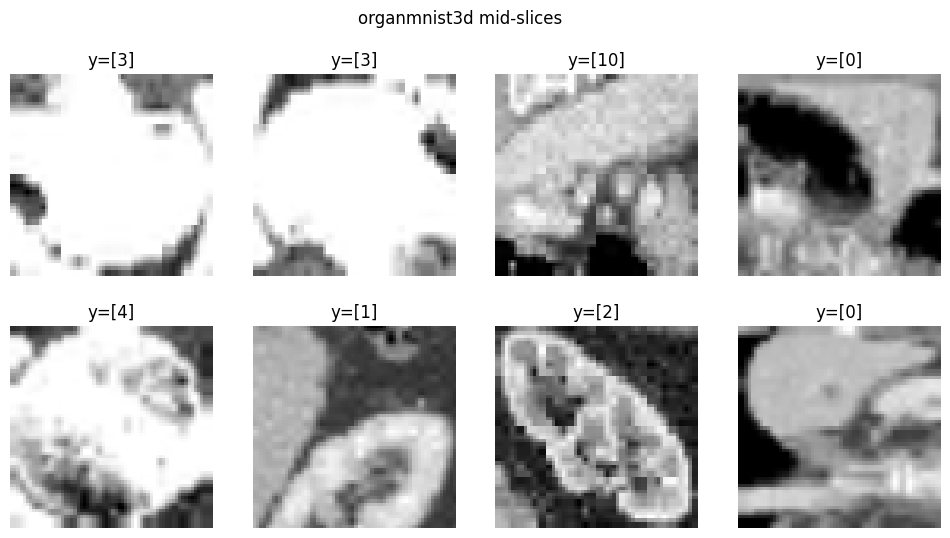

Epoch 1: train=0.225, val=0.435
Epoch 2: train=0.427, val=0.602
Epoch 3: train=0.518, val=0.839
Epoch 4: train=0.609, val=0.907
Epoch 5: train=0.653, val=0.851
Epoch 6: train=0.688, val=0.932
Epoch 7: train=0.699, val=0.832
Epoch 8: train=0.735, val=0.932
Epoch 9: train=0.755, val=0.894
Epoch 10: train=0.786, val=0.975
Test accuracy: 0.7245901639344262
True=10, Pred=10, probs=[[1.5441403e-04 6.6898372e-03 7.3570241e-03 4.7924300e-04 2.2700282e-03
  2.8228119e-03 1.4243191e-06 1.3949274e-07 8.0382222e-07 3.5848110e-03
  9.7663957e-01]]


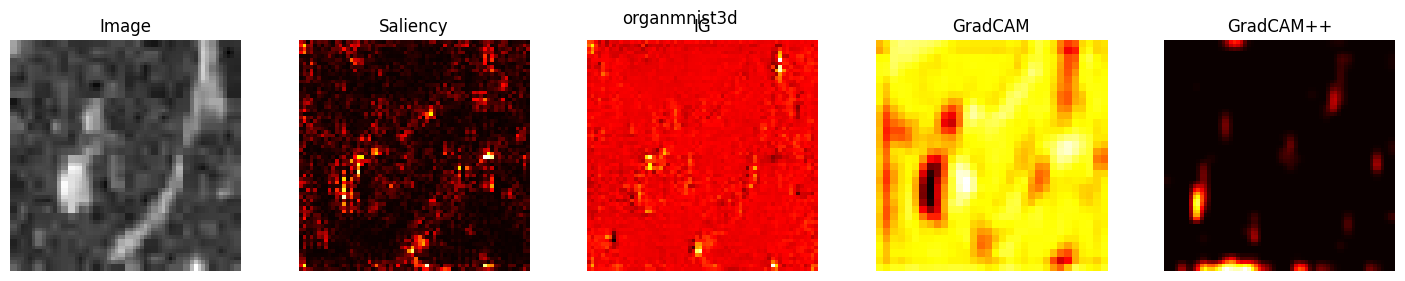

In [ ]:
flag = "organmnist3d"
spatial_size = (64,64,64)

train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, info = load_medmnist_3d(
    flag=flag,
    batch_size=4,
    spatial_size=spatial_size
)

EDA_3D(train_ds, title=flag)

num_classes = len(info["label"])
model = CNN3D(num_classes=num_classes, input_shape=spatial_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    tr = train_one_epoch(model, train_loader, optimizer, criterion)
    va = evaluate(model, val_loader)
    print(f"Epoch {epoch+1}: train={tr:.3f}, val={va:.3f}")

print("Test accuracy:", evaluate(model, test_loader))

x_batch, y_batch = next(iter(test_loader))
x_sample = x_batch[0:1]
y_true = y_batch[0].item()

with torch.no_grad():
    logits = model(x_sample.to(device))
    probs = F.softmax(logits, dim=1)
    pred_class = probs.argmax(1).item()

print(f"True={y_true}, Pred={pred_class}, probs={probs.cpu().numpy()}")

sal, ig, gc = get_saliency_ig_gc(model, x_sample, target_class=pred_class)
gcpp = GradCAMpp3D(model, model.conv2)(x_sample.to(device), target_class=pred_class)

vol = x_sample[0,0].numpy()
visualize_3d_attributions(vol, sal, ig, gc, gcpp, title=flag)
